In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/breast-cancer.csv")

In [ ]:
df

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events
...,...,...,...,...,...,...,...,...,...,...
267,50-59,ge40,30-34,6-8,True,2,left,left_low,False,false-recurrence-events
268,50-59,premefalse,25-29,3-5,True,2,left,left_low,True,false-recurrence-events
269,30-39,premefalse,30-34,6-8,True,2,right,right_up,False,false-recurrence-events
270,50-59,premefalse,15-19,0-2,False,2,right,left_low,False,false-recurrence-events


In [ ]:
# EDA -Explory Data analysis
# 1.null values
# 2.duplicates
# 3.outliers
# 4.label encoding

In [ ]:
#checking for null values
df.isnull().sum()

,0
age,0
mefalsepause,0
tumor-size,0
inv-falsedes,0
falsede-caps,8
deg-malig,0
breast,0
breast-quad,1
irradiat,0
class,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
#checking for the duplicate value
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           263 non-null    object
 1   mefalsepause  263 non-null    object
 2   tumor-size    263 non-null    object
 3   inv-falsedes  263 non-null    object
 4   falsede-caps  263 non-null    object
 5   deg-malig     263 non-null    int64 
 6   breast        263 non-null    object
 7   breast-quad   263 non-null    object
 8   irradiat      263 non-null    bool  
 9   class         263 non-null    object
dtypes: bool(1), int64(1), object(8)
memory usage: 20.8+ KB


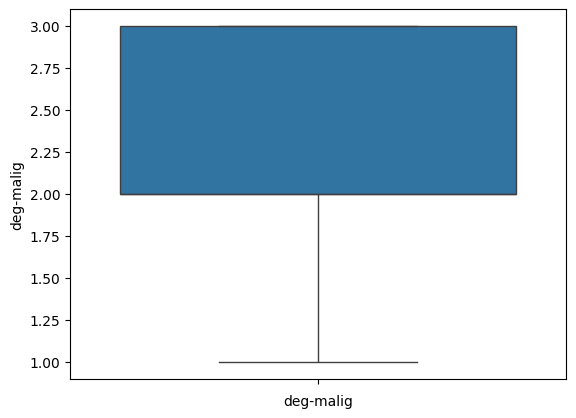

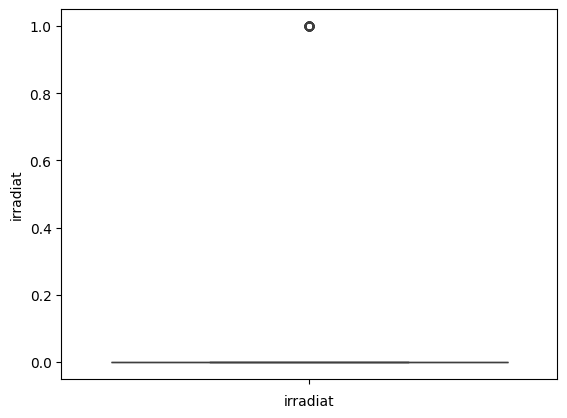

In [ ]:
for col in df.columns:
  if (df[col].dtype !='object'):
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col])
    for code, category in enumerate(le.classes_):
      print(f"{category}-> {code}")
    print()

20-29-> 0
30-39-> 1
40-49-> 2
50-59-> 3
60-69-> 4
70-79-> 5

ge40-> 0
lt40-> 1
premefalse-> 2

0-4-> 0
10-14-> 1
15-19-> 2
20-24-> 3
25-29-> 4
30-34-> 5
35-39-> 6
40-44-> 7
45-49-> 8
5-9-> 9
50-54-> 10

0-2-> 0
12-14-> 1
15-17-> 2
24-26-> 3
3-5-> 4
6-8-> 5
9-11-> 6

False-> 0
True-> 1

left-> 0
right-> 1

central-> 0
left_low-> 1
left_up-> 2
right_low-> 3
right_up-> 4

false-recurrence-events-> 0
recurrence-events-> 1



In [ ]:
from inspect import modulesbyfile

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=70)

In [ ]:
from sklearn.tree import DecisionTreeClassifier   #DecisionTreeRegressor

In [ ]:
model=DecisionTreeClassifier(random_state=58)

In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=58)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
y_pred

array([1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1])

In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_pred,y_test)

0.7341772151898734

In [ ]:
cf=confusion_matrix(y_pred,y_test)

<Axes: >

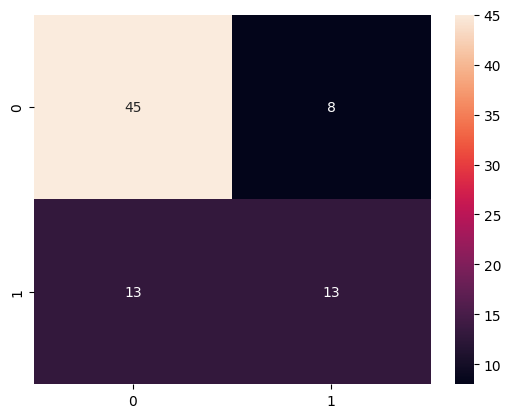

In [ ]:
sns.heatmap(cf,annot=True)

In [ ]:
depth=[1,2,3,4,5,6,7,8,9,10]

In [ ]:
for max_d in depth:
  model=DecisionTreeClassifier(max_depth=max_d,random_state=58)
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  print(f"the accuracy of model for max depth {max_d} is {acc}")

the accuracy of model for max depth 1 is 0.7341772151898734
the accuracy of model for max depth 2 is 0.7468354430379747
the accuracy of model for max depth 3 is 0.7721518987341772
the accuracy of model for max depth 4 is 0.7721518987341772
the accuracy of model for max depth 5 is 0.7468354430379747
the accuracy of model for max depth 6 is 0.7721518987341772
the accuracy of model for max depth 7 is 0.7848101265822784
the accuracy of model for max depth 8 is 0.7341772151898734
the accuracy of model for max depth 9 is 0.7721518987341772
the accuracy of model for max depth 10 is 0.7341772151898734


In [ ]:
final_model=DecisionTreeClassifier(max_depth=7,random_state=58)
final_model.fit(x_train,y_train)
y_pred=final_model.predict(x_test)
acc=accuracy_score(y_test,y_pred)
acc*100

78.48101265822784

In [ ]:
confusion_matrix(y_test,y_pred)

array([[49,  9],
       [ 8, 13]])

<Axes: >

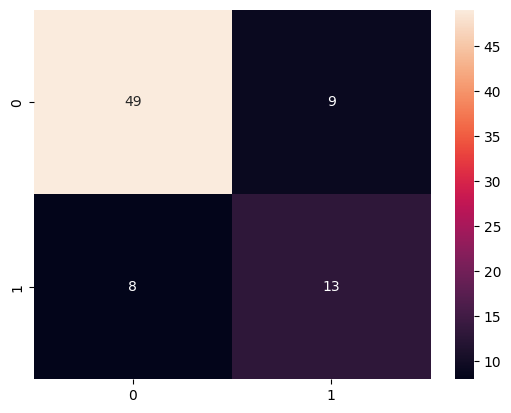

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [ ]:
from sklearn.tree import plot_tree

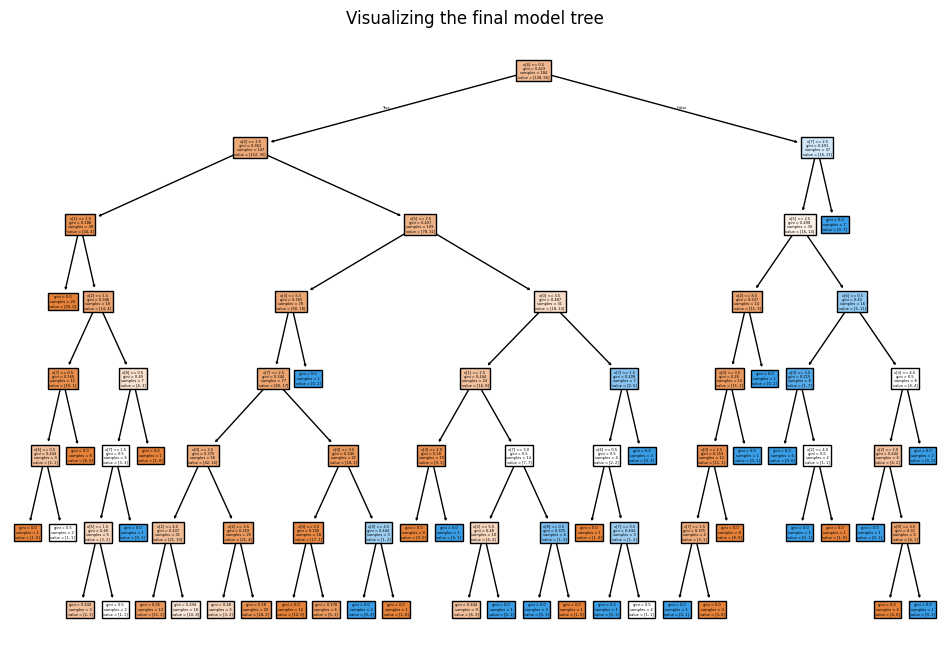

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(final_model,filled=True)
plt.title("Visualizing the final model tree")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.7468354430379747